In [51]:
%load_ext autoreload
%autoreload 2
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re

from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os
from pyproj import Proj, Transformer
import requests
from bs4 import BeautifulSoup

#import copernicusmarine as cm

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import eofs
#
# plt.rcParams['text.usetex'] = False
from scipy.stats import pearsonr
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
# dot dataset
gridtype = 'remapcon'
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
print(path)
fig_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/'
ds = xr.open_dataset(path + 'Data/dot_all_30bmedian_goco05c_sig3_1.nc')
print(ds)
# ERA5 remap dataset
ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')

/Users/iw2g24/PycharmProjects/SSH_project/
<xarray.Dataset> Size: 109MB
Dimensions:          (longitude: 360, latitude: 64, time: 196, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 36MB ...
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry 

In [53]:
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
print(path_ds)
WSC_eumetsat_ds = xr.open_dataset(path_ds + 'WSC_eumetsat_masked_v2.nc')
WSC_nsidc_ds = xr.open_dataset(path_ds + 'WSC_nsidc_masked_v2.nc')
sidc_eumetsat_ds = xr.open_dataset(path_ds + 'sidc_eumetsat_masked_v2.nc')
sidc_eumetsat_ds = sidc_eumetsat_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
sidc_nsidc_ds = xr.open_dataset(path_ds + 'sidc_nsidc_masked_v2.nc')
sidc_nsidc_ds = sidc_nsidc_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
tau_nsidc_ds = xr.open_dataset(path_ds + 'tau_nsidc_ds_v4.nc')
tau_eumetsat_ds = xr.open_dataset(path_ds + 'tau_eumetsat_ds_v4.nc')
# tau_nsidc_ds = xr.open_dataset(path + 'tau_nsidc_ds_v3.nc')
# tau_eumetsat_ds = xr.open_dataset(path + 'tau_eumetsat_ds_v3.nc')
dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
OSC_eumetsat_ds = xr.open_dataset(path_ds + 'OSC_eumetsat_ds_v2.nc')
OSC_nsidc_ds = xr.open_dataset(path_ds + 'OSC_nsidc_ds_v2.nc')
SIC_eu_2015_xa = xr.open_dataset(path_ds + 'sic_masked_eumetsat.nc')
SIC_eu_full_ds = xr.open_dataset(path_ds + 'sic_eumetsat_cleaned_1970_2020.nc')

/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/


In [54]:
print(SIC_eu_2015_xa.time)
print(SIC_eu_full_ds.time)

<xarray.DataArray 'time' (time: 162)> Size: 1kB
array(['2002-07-01T00:00:00.000000000', '2002-08-01T00:00:00.000000000',
       '2002-09-01T00:00:00.000000000', '2002-10-01T00:00:00.000000000',
       '2002-11-01T00:00:00.000000000', '2002-12-01T00:00:00.000000000',
       '2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       '2003-05-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-07-01T00:00:00.000000000', '2003-08-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-10-01T00:00:00.000000000',
       '2003-11-01T00:00:00.000000000', '2003-12-01T00:00:00.000000000',
       '2004-01-01T00:00:00.000000000', '2004-02-01T00:00:00.000000000',
       '2004-03-01T00:00:00.000000000', '2004-04-01T00:00:00.000000000',
       '2004-05-01T00:00:00.000000000', '2004-06-01T00:00:00.000000000',
       '2004-07-01T00:00:00.000000000', '2004-08-01T00:00:00.000000000',
   

In [55]:
print(dot_masked_ds)
dot_masked_ds = dot_masked_ds.rename({'lon': 'lat', 'lat':'lon'})
print(dot_masked_ds)

<xarray.Dataset> Size: 36MB
Dimensions:  (time: 196, lon: 64, lat: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
  * lon      (lon) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * lat      (lat) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    SSH      (time, lon, lat) float64 36MB ...
<xarray.Dataset> Size: 36MB
Dimensions:  (time: 196, lat: 64, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
  * lat      (lat) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    SSH      (time, lat, lon) float64 36MB ...


In [56]:
lon = dot_masked_ds['lon'].values
lat = dot_masked_ds['lat'].values

In [57]:
weights_dot_masked = np.cos(np.deg2rad(dot_masked_ds['lat'])) #grid spacing using cos
weights_dot_masked = weights_dot_masked / weights_dot_masked.sum() #normalise wieghts
weights_dot_masked = np.sqrt(weights_dot_masked)
weights_2d_masked = weights_dot_masked.broadcast_like(dot_masked_ds['SSH'].isel(time=0)) #broadcast to 2d
print(weights_2d_masked.shape)


(64, 360)


In [58]:
print(weights_2d_masked.shape)
print(dot_masked_ds['SSH'].shape)

(64, 360)
(196, 64, 360)


<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([23.17006104, 10.97764677])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


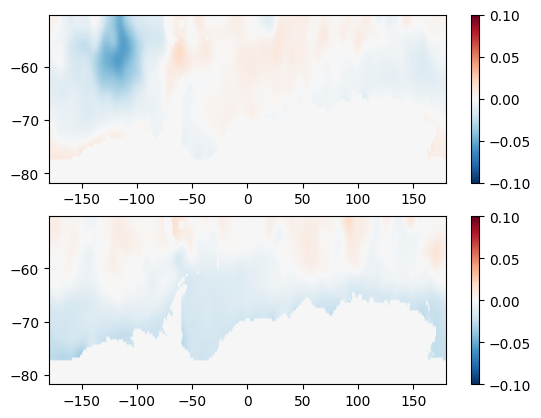

In [59]:
import eofs
from eofs.xarray import Eof

dot_masked_xa = dot_masked_ds['SSH']
neofs = 2
solver = Eof(dot_masked_ds['SSH'], weights=weights_2d_masked)
eofvar_ssh = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_ssh)


nlat, nlon = dot_masked_ds['lat'], dot_masked_ds['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)

plt.show()

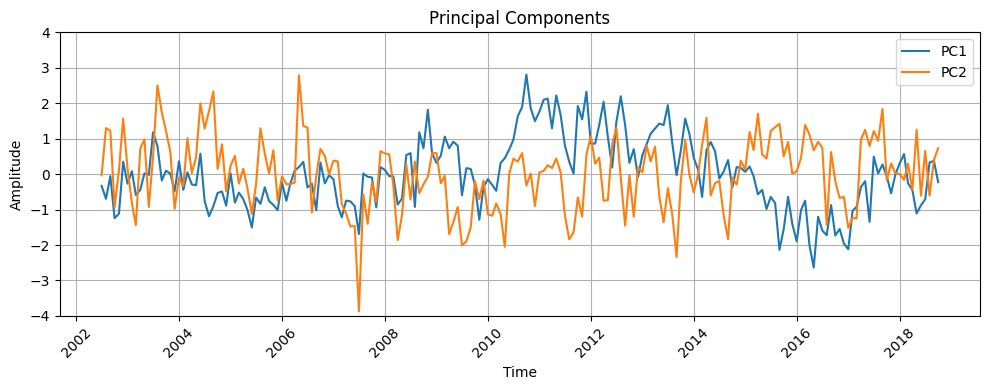

Correlation: 0.000, p-value: 1.000e+00


In [60]:
pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_ssh = pcs[:, 0]
pc2_ssh = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh, label='PC1')
plt.plot(dot_masked_xa.time, pc2_ssh, label='PC2')
plt.legend()
plt.title("Principal Components")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh, pc2_ssh)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")


<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([36.56495772, 10.22426205])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


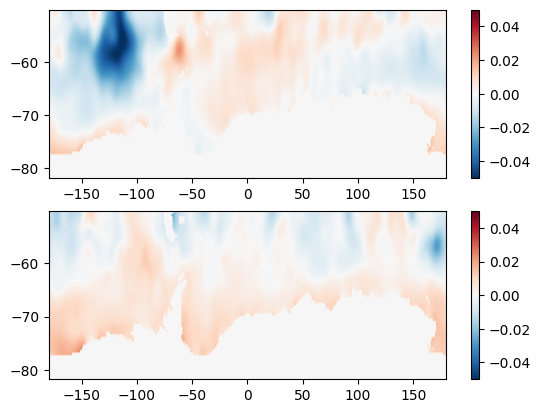

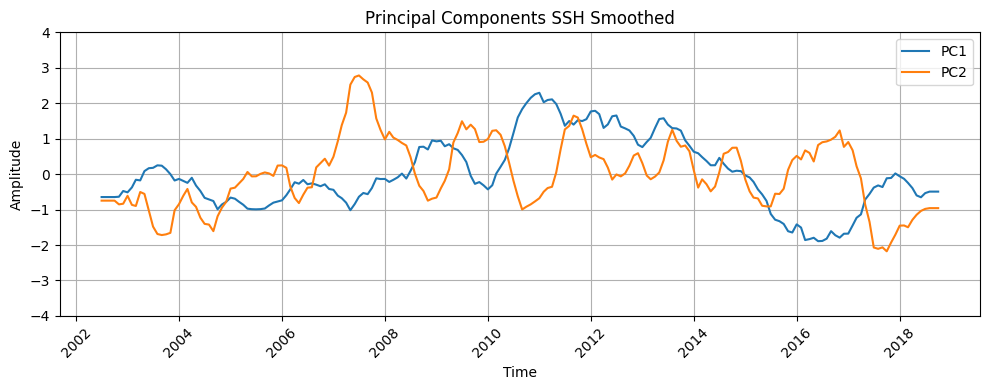

In [61]:

# smoothed_ssh = dot_masked_ds['SSH'].rolling(time=4, center=True).mean()
smoothed_ssh = dot_masked_ds['SSH'].rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_ssh = smoothed_ssh.ffill('time').bfill('time')

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

solver = Eof(smoothed_ssh, weights=weights_2d_masked)
eofvar_ssh_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_ssh_sm)
neofs = 2

nlat, nlon = dot_masked_ds['lat'], dot_masked_ds['lon']

covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.05, 0.05)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.05, 0.05)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_ssh_sm = pcs[:, 0]
pc2_ssh_sm = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1')
plt.plot(dot_masked_xa.time, pc2_ssh_sm, label='PC2')
plt.legend()
plt.title("Principal Components SSH Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



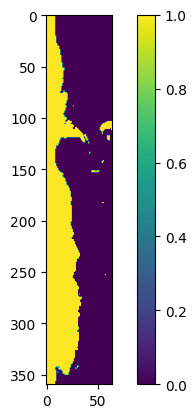

In [62]:

land_mask = (ds['land_mask'])
plt.imshow(land_mask)
plt.colorbar()

<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([9.43966531, 4.90588717])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


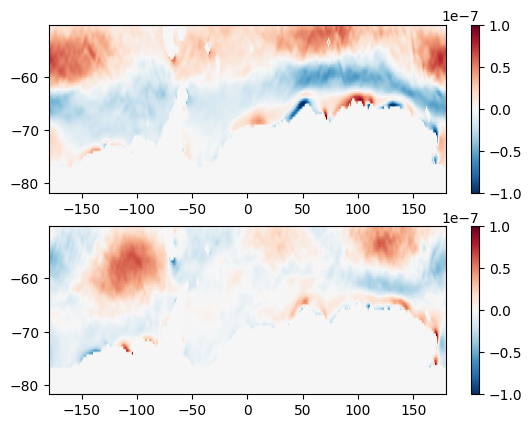

In [63]:
import eofs
from eofs.xarray import Eof

wsc_masked_xa = WSC_eumetsat_ds['WSC']

solver = Eof(wsc_masked_xa, weights=weights_2d_masked)
eofvar_wsc = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_wsc)
neofs = 2

nlat, nlon = WSC_eumetsat_ds['lat'], WSC_eumetsat_ds['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)

plt.show()


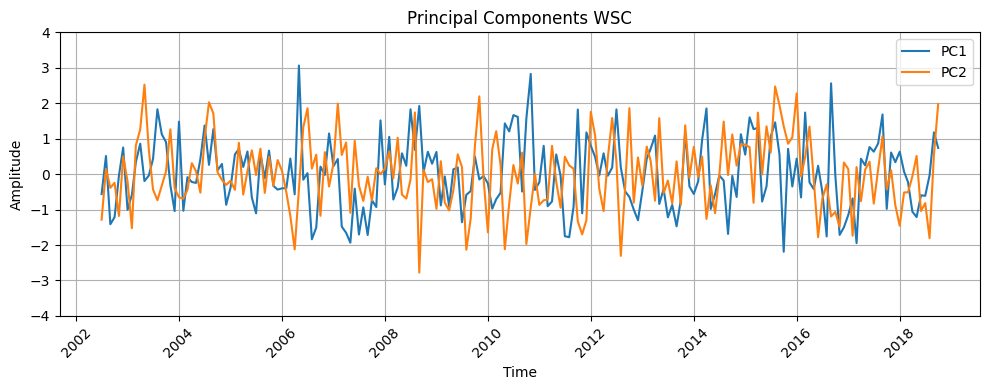

In [64]:
pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_wsc = pcs[:, 0]
pc2_wsc = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_wsc, label='PC1')
plt.plot(dot_masked_xa.time, pc2_wsc, label='PC2')
plt.legend()
plt.title("Principal Components WSC")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([14.3185141 ,  8.68314605])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


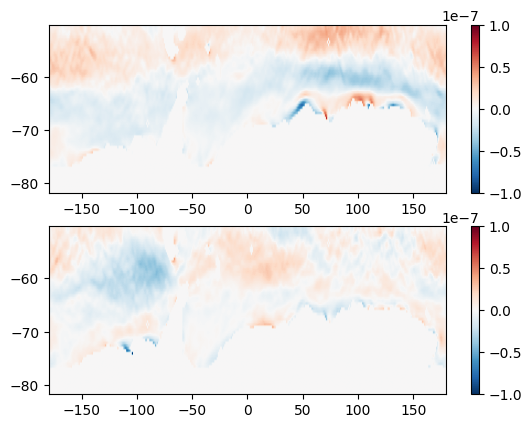

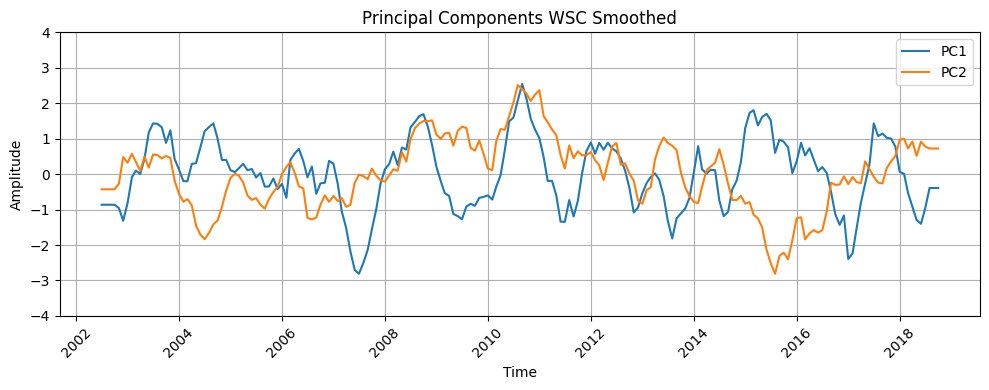

In [65]:

# smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=6, center=True).mean()
# Fill missing values (NaNs) with 0
smoothed_wsc = smoothed_wsc.ffill('time').bfill('time')

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

solver = Eof(smoothed_wsc, weights=weights_2d_masked)
eofvar_wsc_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_wsc_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

solver = Eof(smoothed_wsc, weights=weights_2d_masked)
neofs = 2

nlat, nlon = WSC_eumetsat_ds['lat'], WSC_eumetsat_ds['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_wsc_sm = pcs[:, 0]
pc2_wsc_sm = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_wsc_sm, label='PC1')
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2')
plt.legend()
plt.title("Principal Components WSC Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [66]:
print(SIC_eu_full_ds['time'][281], SIC_eu_full_ds['time'][-28])
print(dot_masked_xa.time[:-1])

<xarray.DataArray 'time' ()> Size: 8B
array('2002-07-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2002-07-01 <xarray.DataArray 'time' ()> Size: 8B
array('2018-09-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2018-09-01
<xarray.DataArray 'time' (time: 195)> Size: 2kB
array(['2002-07-01T00:00:00.000000000', '2002-08-01T00:00:00.000000000',
       '2002-09-01T00:00:00.000000000', '2002-10-01T00:00:00.000000000',
       '2002-11-01T00:00:00.000000000', '2002-12-01T00:00:00.000000000',
       '2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       '2003-05-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-07-01T00:00:00.000000000', '2003-08-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-10-01T00:00:00.000000000',
       '2003-11-01T00:00:00.000000000', '2003-12-01T00:0

<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([9.26175943, 6.24177312])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


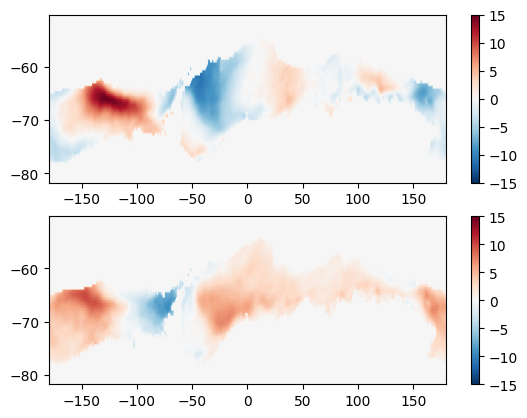

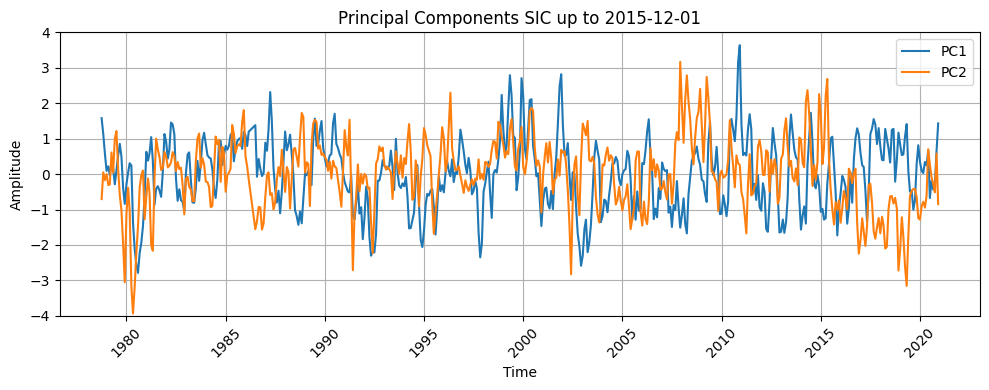

In [67]:

#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# sic = SIC_eu_2015_xa['seaice_xa_masked']
sic = SIC_eu_full_ds['seaice_xa_masked_final']

solver = Eof(sic, weights=weights_2d_masked)
eofvar_sic = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_sic)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_full_ds['lat'], SIC_eu_full_ds['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_sic = pcs[:, 0]
pc2_sic = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time, pc1_sic, label='PC1')
plt.plot(SIC_eu_full_ds.time, pc2_sic, label='PC2')
plt.legend()
plt.title("Principal Components SIC up to 2015-12-01")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([9.26175943, 6.24177312])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


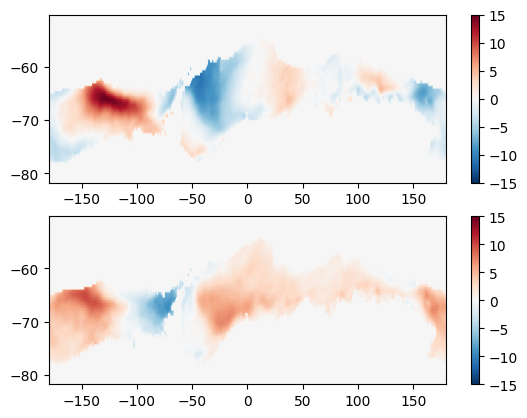

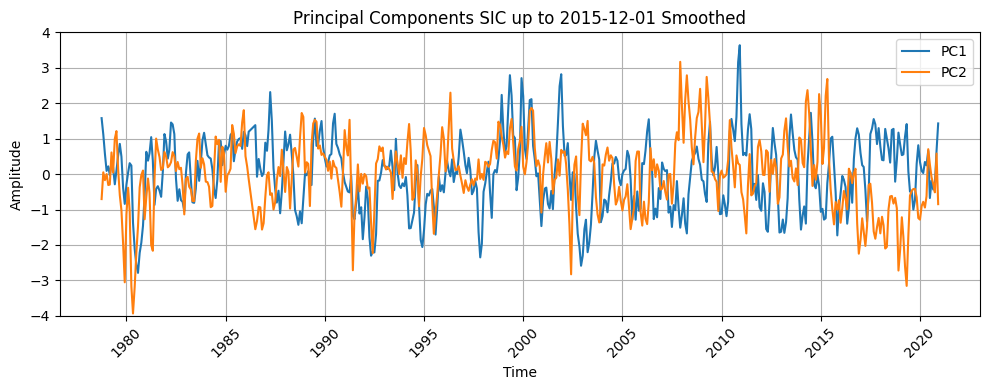

In [68]:

#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
smoothed_sic = SIC_eu_full_ds['seaice_xa_masked_final'].rolling(time=6, center=True).mean()
# Fill missing values (NaNs) with 0
smoothed_sic = smoothed_sic.ffill('time').bfill('time')

solver = Eof(sic, weights=weights_2d_masked)
eofvar_sic_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_sic_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_sic_sm = pcs[:, 0]
pc2_sic_sm = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time, pc1_sic_sm, label='PC1')
plt.plot(SIC_eu_full_ds.time, pc2_sic_sm, label='PC2')
plt.legend()
plt.title("Principal Components SIC up to 2015-12-01 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



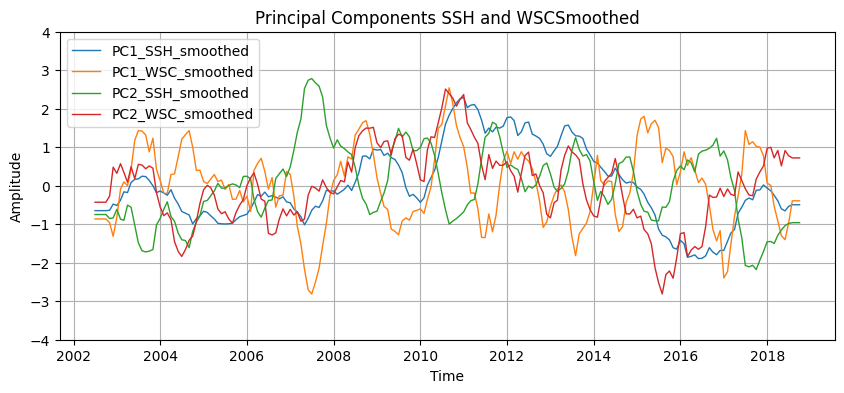

In [69]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc1_wsc_sm, label='PC1_WSC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_ssh_sm, label='PC2_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=1)
plt.legend()
plt.title("Principal Components SSH and WSCSmoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

Correlation: 0.156, p-value: 2.925e-02


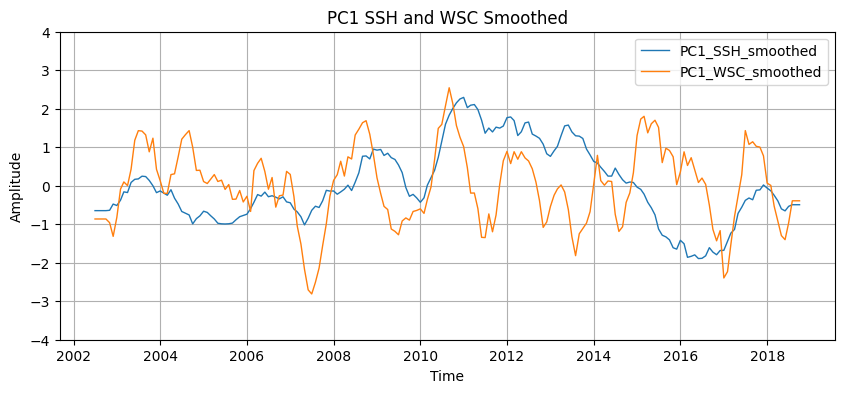

In [70]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc1_wsc_sm, label='PC1_WSC_smoothed', linewidth=1)
plt.legend()
plt.title("PC1 SSH and WSC Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc1_wsc_sm)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")

Correlation: -0.014, p-value: 8.485e-01


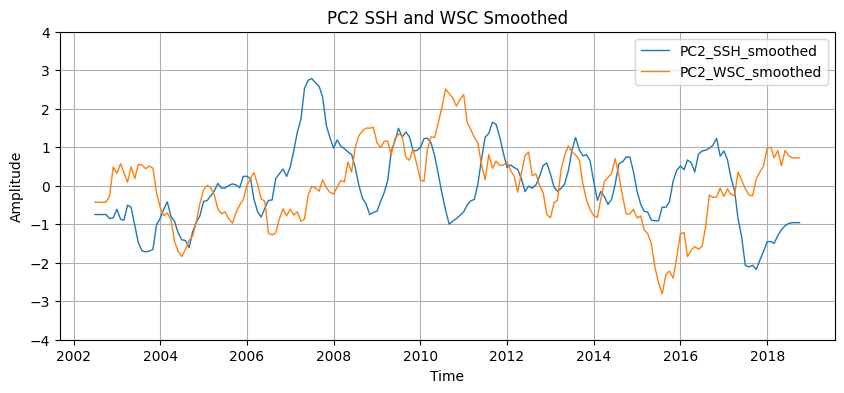

In [71]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc2_ssh_sm, label='PC2_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=1)
plt.legend()
plt.title("PC2 SSH and WSC Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc2_ssh_sm, pc2_wsc_sm)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")

Correlation: 0.671, p-value: 4.784e-27


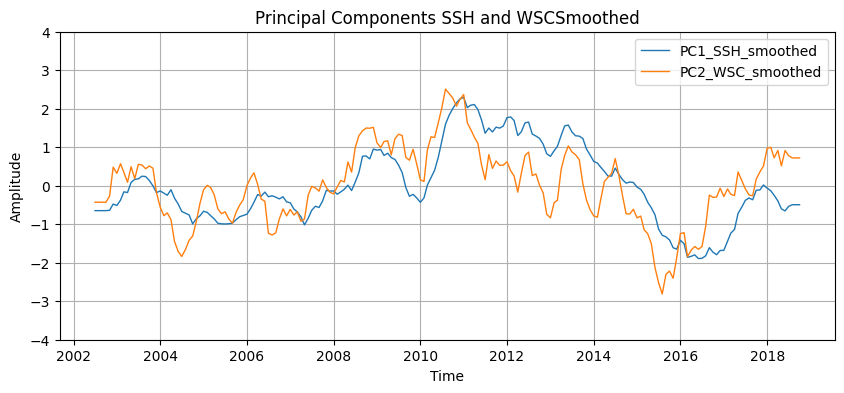

In [72]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=1)
plt.legend()
plt.title("Principal Components SSH and WSCSmoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)


# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc2_wsc_sm)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")

Correlation: -0.598, p-value: 2.334e-20


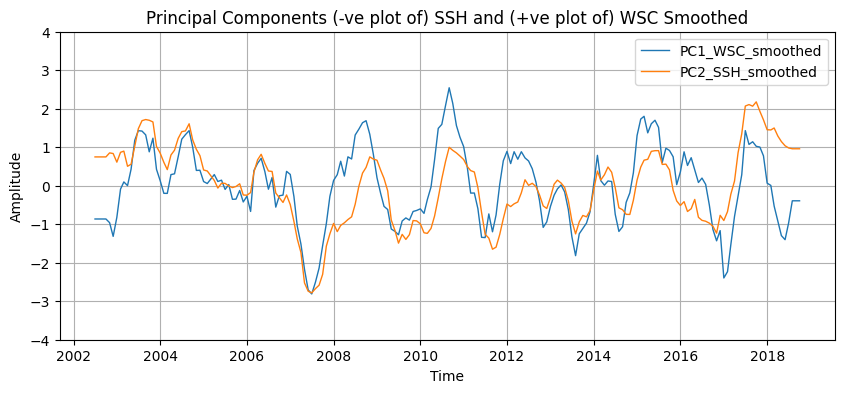

In [103]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_wsc_sm, label='PC1_WSC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time,-pc2_ssh_sm, label='PC2_SSH_smoothed', linewidth=1)
plt.legend()
plt.title("Principal Components (-ve plot of) SSH and (+ve plot of) WSC Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc2_ssh_sm, pc1_wsc_sm)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")

Correlation pc1_ssh-pc1_sic: 0.217, p-value: 2.200e-03
Correlation pc2_ssh-pc2_sic: 0.181, p-value: 1.119e-02
Correlation pc1_ssh-pc2_sic: 0.308, p-value: 1.109e-05
Correlation pc2_ssh-pc1_sic: -0.218, p-value: 2.126e-03


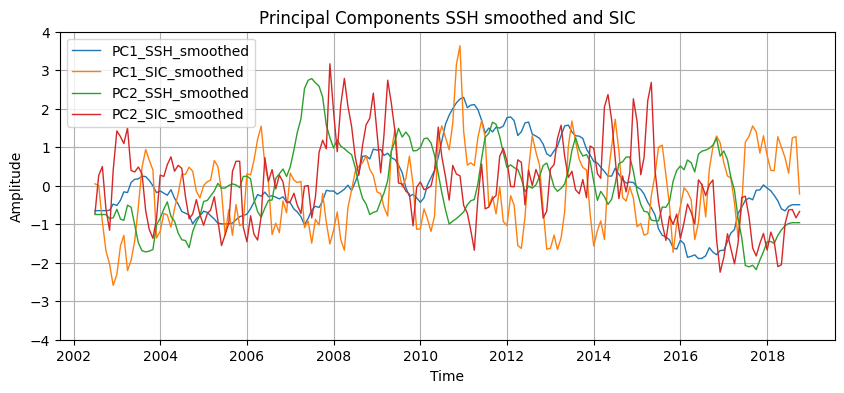

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc1_sic_sm[281:-26], label='PC1_SIC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_ssh_sm, label='PC2_SSH_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_sic_sm[281:-26], label='PC2_SIC_smoothed', linewidth=1)
plt.legend()
plt.title("Principal Components SSH smoothed and SIC")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc1_sic_sm[281:-26])
print(f"Correlation pc1_ssh-pc1_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc2_ssh_sm, pc2_sic_sm[281:-26])
print(f"Correlation pc2_ssh-pc2_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc2_sic_sm[281:-26])
print(f"Correlation pc1_ssh-pc2_sic: {r:.3f}, p-value: {p:.3e}")


# Compute Pearson correlation
r, p = pearsonr(pc2_ssh_sm, pc1_sic_sm[281:-26])
print(f"Correlation pc2_ssh-pc1_sic: {r:.3f}, p-value: {p:.3e}")

Correlation pc1_wsc-pc1_sic: 0.141, p-value: 4.791e-02
Correlation pc2_wsc-pc2_sic: 0.128, p-value: 7.479e-02
Correlation pc1_wsc-pc2_sic: 0.171, p-value: 1.680e-02
Correlation pc2_wsc-pc1_sic: 0.361, p-value: 1.998e-07


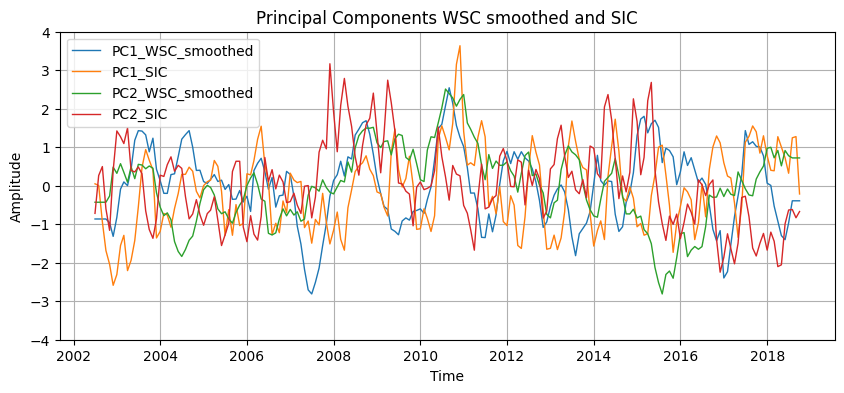

In [75]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_wsc_sm, label='PC1_WSC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc1_sic[281:-26], label='PC1_SIC', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc2_sic[281:-26], label='PC2_SIC', linewidth=1)
plt.legend()
plt.title("Principal Components WSC smoothed and SIC")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc1_wsc_sm, pc1_sic[281:-26])
print(f"Correlation pc1_wsc-pc1_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc2_wsc_sm, pc2_sic[281:-26])
print(f"Correlation pc2_wsc-pc2_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc1_wsc_sm, pc2_sic[281:-26])
print(f"Correlation pc1_wsc-pc2_sic: {r:.3f}, p-value: {p:.3e}")


# Compute Pearson correlation
r, p = pearsonr(pc2_wsc_sm, pc1_sic[281:-26])
print(f"Correlation pc2_wsc-pc1_sic: {r:.3f}, p-value: {p:.3e}")

Correlation pc1_wsc-pc1_sic: 0.217, p-value: 2.200e-03
Correlation pc2_wsc-pc2_sic: 0.128, p-value: 7.479e-02
Correlation pc1_wsc-pc2_sic: 0.308, p-value: 1.109e-05
Correlation pc2_wsc-pc1_sic: 0.361, p-value: 1.998e-07


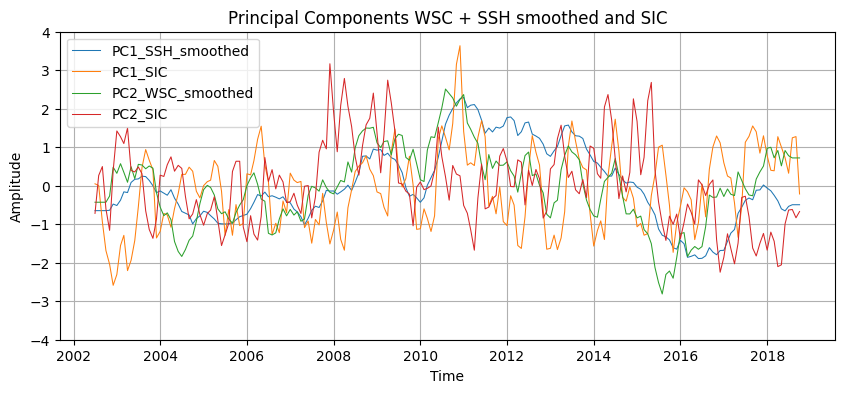

In [76]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=0.75)
plt.plot(dot_masked_xa.time, pc1_sic[281:-26], label='PC1_SIC', linewidth=0.75)
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=0.75)
plt.plot(dot_masked_xa.time, pc2_sic[281:-26], label='PC2_SIC', linewidth=0.75)
plt.legend()
plt.title("Principal Components WSC + SSH smoothed and SIC")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc1_sic[281:-26])
print(f"Correlation pc1_wsc-pc1_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc2_wsc_sm, pc2_sic[281:-26])
print(f"Correlation pc2_wsc-pc2_sic: {r:.3f}, p-value: {p:.3e}")

# Compute Pearson correlation
r, p = pearsonr(pc1_ssh_sm, pc2_sic[281:-26])
print(f"Correlation pc1_wsc-pc2_sic: {r:.3f}, p-value: {p:.3e}")


# Compute Pearson correlation
r, p = pearsonr(pc2_wsc_sm, pc1_sic[281:-26])
print(f"Correlation pc2_wsc-pc1_sic: {r:.3f}, p-value: {p:.3e}")

In [77]:
#trying to do linear regression between NPP and ZW3 and SOI
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

ds_zw3 = xr.open_dataset(path + 'zw3_ds.nc')

ds_monthly_SOI = xr.open_dataset(path + 'monthly_SOI.nc')
ds_monthly_SOI_masked = xr.open_dataset(path + 'soi_sam_masked.nc')

formatted_time_zw3 = pd.to_datetime(ds_zw3['valid_time'].values).strftime('%Y-%m-%dT%H:%M:%S.000000000')
ds_zw3 = ds_zw3.assign_coords(valid_time=("valid_time", formatted_time_zw3))
ds_zw3 = ds_zw3.assign_coords(valid_time=pd.to_datetime(ds_zw3['valid_time'].values))

formatted_time_soi = pd.to_datetime(ds_monthly_SOI['time'].values).strftime('%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=("time", formatted_time_soi))
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=pd.to_datetime(ds_monthly_SOI['time'].values))

formatted_time_soi_masked = pd.to_datetime(ds_monthly_SOI_masked['time'].values).strftime(
    '%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=("time", formatted_time_soi_masked))
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=pd.to_datetime(ds_monthly_SOI_masked['time'].values))
smoothed_soi = ds_monthly_SOI_masked['SOI'].rolling(time=6, center=True).mean()
smoothed_zw3_idx = ds_zw3['zw3index_magnitude'].rolling(valid_time=6, center=True).mean()

In [78]:
# sic_time = SIC_eu_2015_xa.time.values # shape (288,)
sic_time = SIC_eu_full_ds['time'].values
zw3_time = ds_zw3['valid_time'].values  # shape (252,)
soi_time = ds_monthly_SOI['time'].values  #shape (1908)
ssh_time = dot_masked_xa.time
wsc_time = dot_masked_xa.time

start = max(sic_time.min(), zw3_time.min(), soi_time.min(), ssh_time.min(), wsc_time.min())
end = min(sic_time.max(), zw3_time.max(), soi_time.max(), ssh_time.max(), wsc_time.max())

start = start.values
end = end.values

sic_idx = np.where((sic_time >= start) & (sic_time <= end))[0]
zw3_idx = np.where((zw3_time >= start) & (zw3_time <= end))[0]
soi_idx = np.where((soi_time >= start) & (soi_time <= end))[0]
ssh_idx = np.where((ssh_time >= start) & (ssh_time <= end))[0]
wsc_idx = np.where((wsc_time >= start) & (wsc_time <= end))[0]



In [139]:
zw3_idx

array([ 30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
       173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,
       186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198,
       199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 21

In [79]:
print(start)
print(end)

2002-07-01T00:00:00.000000000
2018-10-01T00:00:00.000000000


In [80]:
print('len sic times', len(sic_idx))
print('len zw3 times', len(zw3_idx))
print('len soi times', len(soi_idx))
print('len ssh times', len(ssh_idx))
print('len wsc times', len(wsc_idx))
ZW3_aligned = ds_zw3.isel(valid_time=zw3_idx)
SOI_aligned_monthly = ds_monthly_SOI.isel(time=soi_idx)
SOI_aligned_monthly_masked = ds_monthly_SOI_masked.isel(time=soi_idx)
sic_aligned = SIC_eu_full_ds.isel(time=sic_idx)
ssh_aligned = dot_masked_ds.isel(time=ssh_idx)
wsc_aligned = WSC_eumetsat_ds.isel(time=wsc_idx)

len sic times 196
len zw3 times 196
len soi times 196
len ssh times 196
len wsc times 196


In [81]:
print(ZW3_aligned.keys)
print(SOI_aligned_monthly.keys)
print(SOI_aligned_monthly_masked.keys)
print(sic_aligned.keys)
print(ssh_aligned.keys)
print(wsc_aligned.keys)

<bound method Mapping.keys of <xarray.Dataset> Size: 8kB
Dimensions:             (valid_time: 196)
Coordinates:
  * valid_time          (valid_time) datetime64[ns] 2kB 2002-07-01 ... 2018-1...
Data variables:
    zw3index_magnitude  (valid_time) float64 2kB 1.371 1.226 ... 1.225 2.165
    zw3index_phase      (valid_time) float64 2kB ...
    pc1                 (valid_time) float64 2kB ...
    pc2                 (valid_time) float64 2kB ...>
<bound method Mapping.keys of <xarray.Dataset> Size: 3kB
Dimensions:  (time: 196)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
Data variables:
    SOI      (time) float64 2kB ...>
<bound method Mapping.keys of <xarray.Dataset> Size: 3kB
Dimensions:  (time: 196)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
Data variables:
    SOI      (time) float64 2kB -2.7 -1.3 -1.7 0.3 -1.6 ... 0.5 -0.3 -0.5 -0.6>
<bound method Mapping.keys of <xarray.Dataset> Size: 72MB
Dimen

In [82]:
smoothed_zw3_idx.shape

(288,)

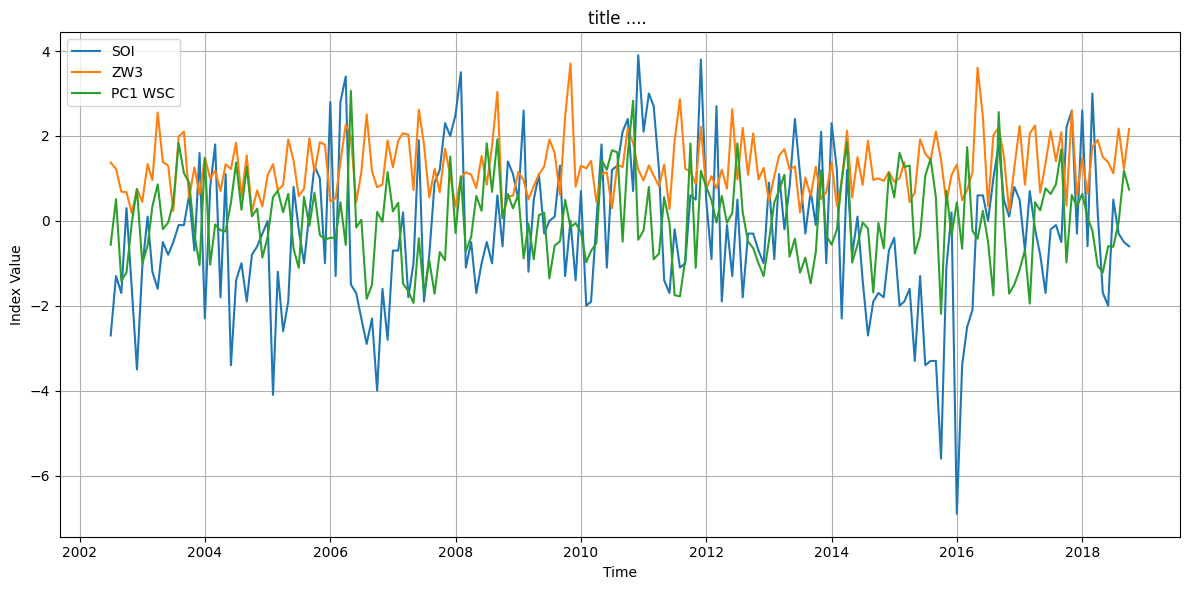

In [83]:
# Plotting
plt.figure(figsize=(12, 6))

plt.plot(SOI_aligned_monthly_masked['time'], SOI_aligned_monthly_masked['SOI'], label='SOI')
plt.plot(ZW3_aligned['valid_time'], ZW3_aligned['zw3index_magnitude'], label='ZW3')
#plt.plot(sic_aligned['time'], pc1_sic, label='PC1 SIC')
plt.plot(wsc_aligned['time'], pc1_wsc, label='PC1 WSC')
#plt.plot(ssh_aligned['time'], pc1_ssh[:162], label='PC1 SSH')

plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('title .... ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [84]:
# Extract 1D numpy arrays
soi_vals = SOI_aligned_monthly_masked['SOI'].values
zw3_vals = ZW3_aligned['zw3index_magnitude'].values
pc1_sic_vals = pc1_sic[281:-26].values
pc2_sic_vals = pc2_sic[281:-26].values
pc1_wsc_vals = pc1_wsc.values
pc2_wsc_vals = pc2_wsc.values
pc1_ssh_vals = pc1_ssh.values
pc2_ssh_vals = pc2_ssh.values


data_matrix = np.vstack([soi_vals, zw3_vals, pc1_sic_vals, pc2_sic_vals, pc1_wsc_vals,pc2_wsc_vals, pc1_ssh_vals,pc2_ssh_vals] )
corr_matrix_spear, _ = np.round(spearmanr(data_matrix, axis=1), 3)
corr_matrix_pearson = np.round(np.corrcoef(data_matrix), 3)

print('Pearson correlation matrix:')
labels = ['SOI', 'ZW3', 'PC1_SIC','PC2_SIC' ,'PC1_WSC','PC2_WSC', 'PC1_SSH','PC2_SSH' ]
corr_df_pearson = pd.DataFrame(corr_matrix_pearson, index=labels, columns=labels)
print(corr_df_pearson)

print('Spearman correlation matrix:')
labels = ['SOI', 'ZW3', 'PC1_SIC','PC2_SIC' ,'PC1_WSC','PC2_WSC', 'PC1_SSH','PC2_SSH' ]
corr_df_spear = pd.DataFrame(corr_matrix_spear, index=labels, columns=labels)
print(corr_df_spear)

Pearson correlation matrix:
           SOI    ZW3  PC1_SIC  PC2_SIC  PC1_WSC  PC2_WSC  PC1_SSH  PC2_SSH
SOI      1.000  0.035    0.168    0.047    0.000   -0.301    0.338   -0.169
ZW3      0.035  1.000    0.093   -0.181    0.110    0.038   -0.158   -0.014
PC1_SIC  0.168  0.093    1.000   -0.277    0.140   -0.125    0.235    0.035
PC2_SIC  0.047 -0.181   -0.277    1.000    0.174   -0.072    0.345   -0.037
PC1_WSC  0.000  0.110    0.140    0.174    1.000   -0.000    0.262    0.564
PC2_WSC -0.301  0.038   -0.125   -0.072   -0.000    1.000   -0.302    0.250
PC1_SSH  0.338 -0.158    0.235    0.345    0.262   -0.302    1.000    0.000
PC2_SSH -0.169 -0.014    0.035   -0.037    0.564    0.250    0.000    1.000
Spearman correlation matrix:
           SOI    ZW3  PC1_SIC  PC2_SIC  PC1_WSC  PC2_WSC  PC1_SSH  PC2_SSH
SOI      1.000  0.014    0.136    0.048   -0.058   -0.274    0.299   -0.187
ZW3      0.014  1.000    0.128   -0.165    0.121    0.043   -0.147   -0.002
PC1_SIC  0.136  0.128    1.000 

In [85]:
from scipy.stats import pearsonr

labels = ['SOI', 'ZW3', 'PC1_SIC', 'PC2_SIC', 'PC1_WSC', 'PC2_WSC', 'PC1_SSH', 'PC2_SSH']
data_arrays = [
    soi_vals, zw3_vals,
    pc1_sic_vals, pc2_sic_vals,
    pc1_wsc_vals, pc2_wsc_vals,
    pc1_ssh_vals, pc2_ssh_vals
]

# Compute pairwise Pearson correlations
print("Pairwise Pearson correlations:\n")
for i in range(len(data_arrays)):
    for j in range(i + 1, len(data_arrays)):
        corr, _ = pearsonr(data_arrays[i], data_arrays[j])
        print(f"{labels[i]} vs {labels[j]}: {corr:.4f}")


Pairwise Pearson correlations:

SOI vs ZW3: 0.0346
SOI vs PC1_SIC: 0.1681
SOI vs PC2_SIC: 0.0468
SOI vs PC1_WSC: 0.0003
SOI vs PC2_WSC: -0.3008
SOI vs PC1_SSH: 0.3384
SOI vs PC2_SSH: -0.1685
ZW3 vs PC1_SIC: 0.0932
ZW3 vs PC2_SIC: -0.1810
ZW3 vs PC1_WSC: 0.1100
ZW3 vs PC2_WSC: 0.0379
ZW3 vs PC1_SSH: -0.1578
ZW3 vs PC2_SSH: -0.0136
PC1_SIC vs PC2_SIC: -0.2771
PC1_SIC vs PC1_WSC: 0.1399
PC1_SIC vs PC2_WSC: -0.1251
PC1_SIC vs PC1_SSH: 0.2348
PC1_SIC vs PC2_SSH: 0.0348
PC2_SIC vs PC1_WSC: 0.1745
PC2_SIC vs PC2_WSC: -0.0719
PC2_SIC vs PC1_SSH: 0.3451
PC2_SIC vs PC2_SSH: -0.0371
PC1_WSC vs PC2_WSC: -0.0000
PC1_WSC vs PC1_SSH: 0.2616
PC1_WSC vs PC2_SSH: 0.5636
PC2_WSC vs PC1_SSH: -0.3015
PC2_WSC vs PC2_SSH: 0.2502
PC1_SSH vs PC2_SSH: 0.0000


In [86]:
#rolling mean for all of the varibales
# ZW3 and SOI
smoothed_soi = SOI_aligned_monthly_masked['SOI'].rolling(time=4, center=True).mean().ffill('time').bfill('time')
smoothed_soi_6 = SOI_aligned_monthly_masked['SOI'].rolling(time=6, center=True).mean().ffill('time').bfill('time')

smoothed_zw3 = ZW3_aligned['zw3index_magnitude'].rolling(valid_time=4, center=True).mean().ffill('valid_time').bfill('valid_time')
smoothed_zw3_6 = ZW3_aligned['zw3index_magnitude'].rolling(valid_time=6, center=True).mean().ffill('valid_time').bfill('valid_time')
# # SIC PCs
# smoothed_pc1_sic = pc1_sic.rolling(time=4, center=True).mean().fillna(0)
# smoothed_pc2_sic = pc2_sic.rolling(time=4, center=True).mean().fillna(0)
#
# # WSC PCs
# smoothed_pc1_wsc = pc1_wsc.rolling(time=4, center=True).mean().fillna(0)
# smoothed_pc2_wsc = pc2_wsc.rolling(time=4, center=True).mean().fillna(0)
#
# # SSH PCs
# smoothed_pc1_ssh = pc1_ssh.rolling(time=4, center=True).mean().fillna(0)
# smoothed_pc2_ssh = pc2_ssh.rolling(time=4, center=True).mean().fillna(0)


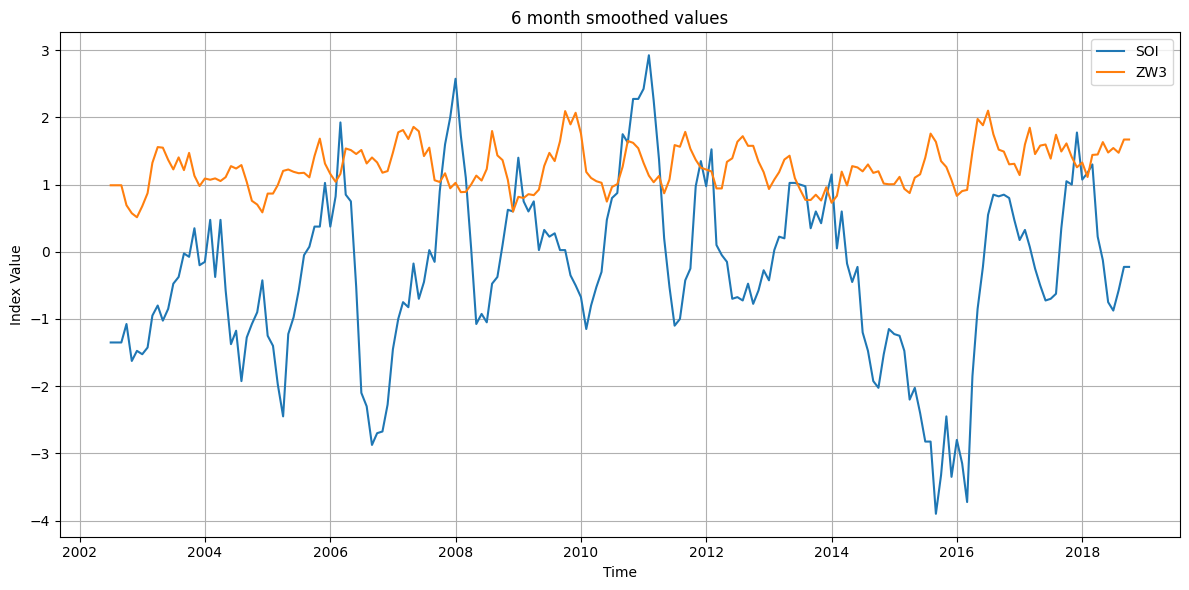

In [105]:
# Plotting
plt.figure(figsize=(12, 6))

plt.plot(smoothed_soi_6['time'], smoothed_soi, label='SOI')
plt.plot(smoothed_zw3_6['valid_time'], smoothed_zw3, label='ZW3')
# plt.plot(pc1_sic_sm['time'][281:-26], pc1_sic_sm[281:-26], label='PC1 SIC')
# plt.plot(pc1_wsc_sm['time'], pc1_wsc_sm, label='PC1 WSC')
# plt.plot(pc1_ssh_sm['time'], pc1_ssh_sm, label='PC1 SSH')

plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6 month smoothed values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [88]:
# Extract 1D numpy arrays
smoothed_soi_vals = smoothed_soi.values
smoothed_zw3_vals = smoothed_zw3.values
smoothed_pc1_sic_vals = pc1_sic_sm[281:-26].values
smoothed_pc2_sic_vals = pc2_sic_sm[281:-26].values
smoothed_pc1_wsc_vals = pc1_wsc_sm.values
smoothed_pc2_wsc_vals = pc2_wsc_sm.values
smoothed_pc1_ssh_vals = pc1_ssh_sm.values
smoothed_pc2_ssh_vals = pc2_ssh_sm.values


smoothed_data_matrix = np.vstack([smoothed_soi_vals, smoothed_zw3_vals, smoothed_pc1_sic_vals, smoothed_pc2_sic_vals, smoothed_pc1_wsc_vals,smoothed_pc2_wsc_vals, smoothed_pc1_ssh_vals,smoothed_pc2_ssh_vals] )
smoothed_corr_matrix_spear, _ = np.round(spearmanr(smoothed_data_matrix, axis=1), 3)
smoothed_corr_matrix_pearson = np.round(np.corrcoef(smoothed_data_matrix), 3)

print('\n\nPearson correlation matrix smoothed values:\n')
labels = ['SOI', 'ZW3', 'PC1_SIC','PC2_SIC' ,'PC1_WSC','PC2_WSC', 'PC1_SSH','PC2_SSH' ]
smoothed_corr_df_pearson = pd.DataFrame(smoothed_corr_matrix_pearson, index=labels, columns=labels)
print(smoothed_corr_df_pearson)

print('\n\nSpearman correlation matrix smoothed values:\n')
labels = ['SOI', 'ZW3', 'PC1_SIC','PC2_SIC' ,'PC1_WSC','PC2_WSC', 'PC1_SSH','PC2_SSH' ]
smoothed_corr_df_spear = pd.DataFrame(smoothed_corr_matrix_spear, index=labels, columns=labels)
print(smoothed_corr_df_spear)



Pearson correlation matrix smoothed values:

           SOI    ZW3  PC1_SIC  PC2_SIC  PC1_WSC  PC2_WSC  PC1_SSH  PC2_SSH
SOI      1.000 -0.006    0.253    0.080   -0.048    0.616    0.474    0.043
ZW3     -0.006  1.000    0.221   -0.298   -0.083   -0.023   -0.160    0.109
PC1_SIC  0.253  0.221    1.000   -0.277    0.141    0.361    0.217   -0.218
PC2_SIC  0.080 -0.298   -0.277    1.000    0.171    0.128    0.308    0.181
PC1_WSC -0.048 -0.083    0.141    0.171    1.000    0.000    0.156   -0.598
PC2_WSC  0.616 -0.023    0.361    0.128    0.000    1.000    0.671   -0.014
PC1_SSH  0.474 -0.160    0.217    0.308    0.156    0.671    1.000    0.000
PC2_SSH  0.043  0.109   -0.218    0.181   -0.598   -0.014    0.000    1.000


Spearman correlation matrix smoothed values:

           SOI    ZW3  PC1_SIC  PC2_SIC  PC1_WSC  PC2_WSC  PC1_SSH  PC2_SSH
SOI      1.000 -0.023    0.233    0.065   -0.061    0.516    0.431    0.083
ZW3     -0.023  1.000    0.225   -0.293   -0.060    0.031   -0.156   

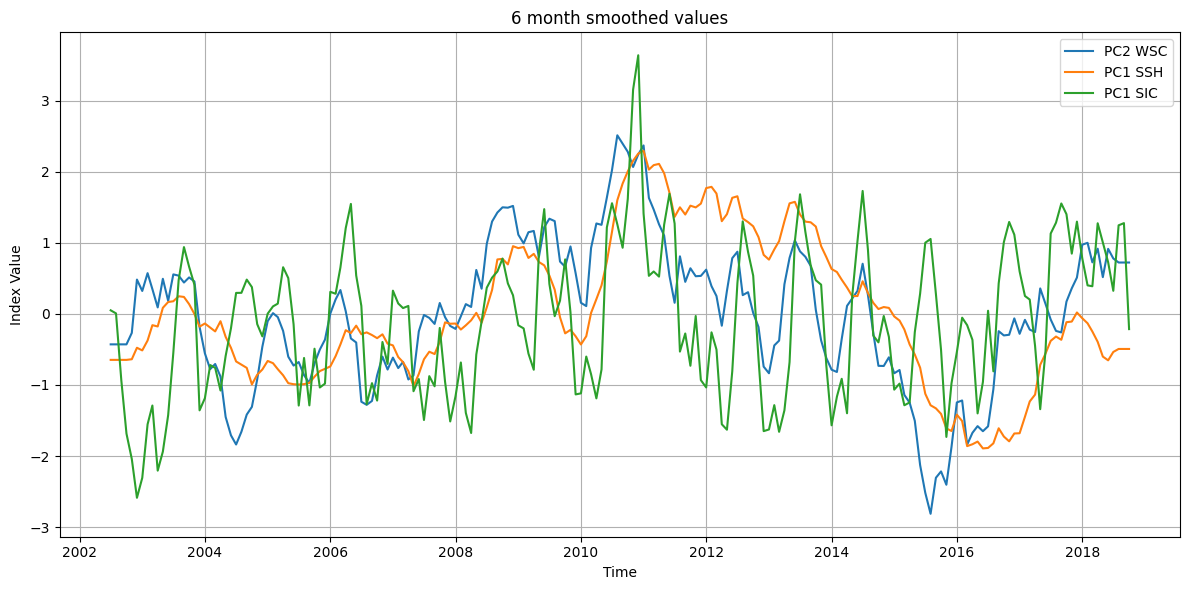

In [89]:
# Plotting
plt.figure(figsize=(12, 6))

#plt.plot(smoothed_soi['time'], smoothed_soi, label='SOI')
#plt.plot(smoothed_zw3['valid_time'], smoothed_zw3, label='ZW3')
#plt.plot(smoothed_pc1_sic['time'], smoothed_pc1_sic, label='PC1 SIC')
plt.plot(pc2_wsc_sm['time'], pc2_wsc_sm, label='PC2 WSC')
plt.plot(pc1_ssh_sm['time'], pc1_ssh_sm, label='PC1 SSH')
#plt.plot(pc2_sic_sm['time'], pc2_sic_sm, label='PC2 SIC')
plt.plot(pc1_sic_sm['time'][281:-26], pc1_sic_sm[281:-26], label='PC1 SIC')

plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6 month smoothed values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



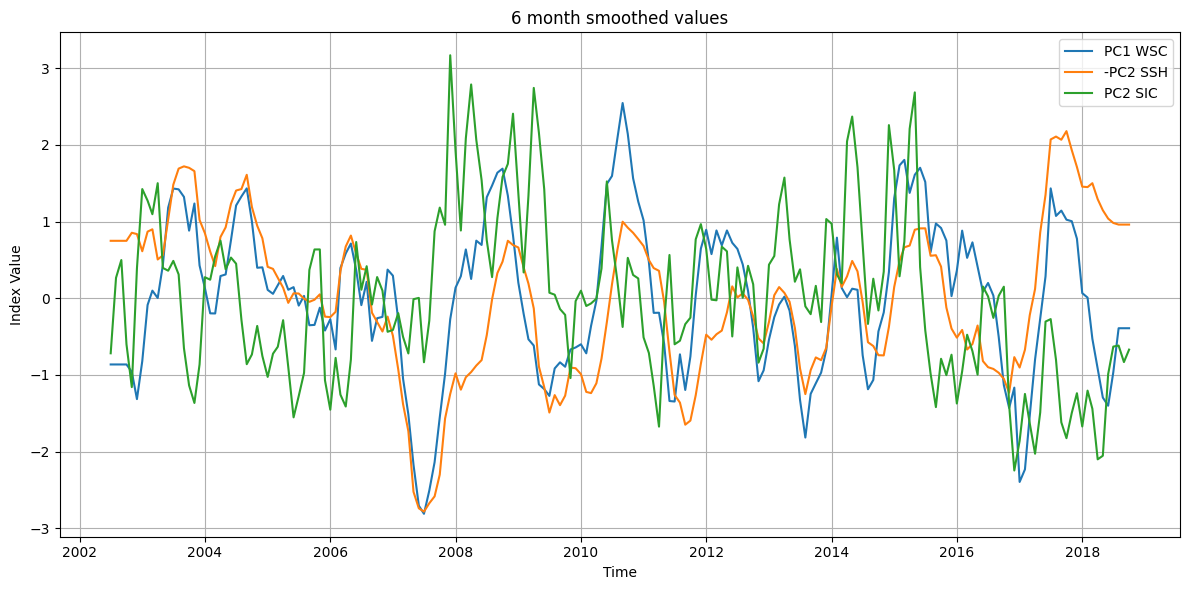

In [107]:
# Plotting
plt.figure(figsize=(12, 6))

#plt.plot(smoothed_soi['time'], smoothed_soi, label='SOI')
#plt.plot(smoothed_zw3['valid_time'], smoothed_zw3, label='ZW3')
#plt.plot(smoothed_pc1_sic['time'], smoothed_pc1_sic, label='PC1 SIC')
plt.plot(pc1_wsc_sm['time'], pc1_wsc_sm, label='PC1 WSC')
plt.plot(pc2_ssh_sm['time'], -pc2_ssh_sm, label='-PC2 SSH')
#plt.plot(pc2_sic_sm['time'], pc2_sic_sm, label='PC2 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], pc2_sic_sm[281:-26], label='PC2 SIC')

plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6 month smoothed values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Correlation: -0.598, p-value: 2.334e-20


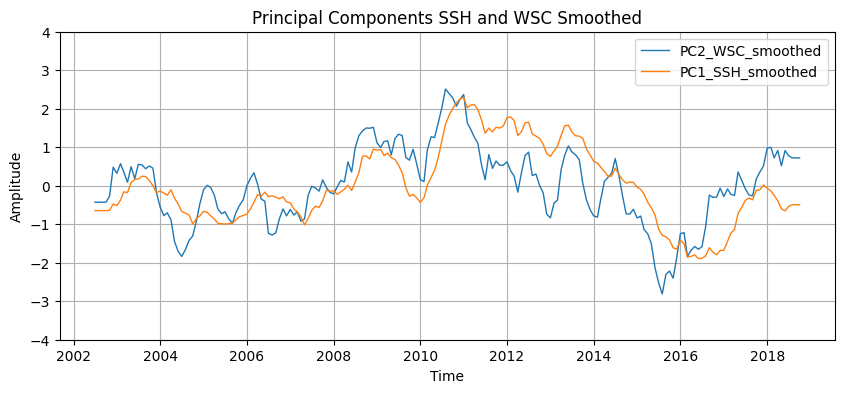

In [108]:
plt.figure(figsize=(10, 4))
plt.plot(dot_masked_xa.time, pc2_wsc_sm, label='PC2_WSC_smoothed', linewidth=1)
plt.plot(dot_masked_xa.time, pc1_ssh_sm, label='PC1_SSH_smoothed', linewidth=1)
plt.legend()
plt.title("Principal Components SSH and WSC Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Compute Pearson correlation
r, p = pearsonr(pc2_ssh_sm, pc1_wsc_sm)
print(f"Correlation: {r:.3f}, p-value: {p:.3e}")

In [135]:
# ## SAVE PCS as TXT files to use to comp to MCA PCA
pcs = {'pc1_ssh_sm': pc1_ssh_sm,  'pc2_ssh_sm': pc2_ssh_sm, 'pc1_wsc_sm':  pc1_wsc_sm, 'pc2_wsc_sm': pc2_wsc_sm, 'pc1_sic_sm': pc1_sic_sm, 'pc2_sic_sm': pc2_sic_sm}

for name, da in pcs.items():
   da.to_netcdf(f"{name}.nc")

In [134]:
print(type(pc1_sic_sm))


<class 'xarray.core.dataarray.DataArray'>


In [91]:
timep1_sic_start = SIC_eu_full_ds['time'][370]
timep1_sic_end= SIC_eu_full_ds['time'][418]
timep2_sic_start = SIC_eu_full_ds['time'][419]
timep2_sic_end = SIC_eu_full_ds['time'][467]

timep1_start = dot_masked_xa.time[89]
timep1_end = dot_masked_xa.time[137]
timep2_start = dot_masked_xa.time[138]
timep2_end = dot_masked_xa.time[186]


In [92]:
print("SIC Time Periods:")
print(" timep1_sic_start:", SIC_eu_full_ds['time'][370].values)
print(" timep1_sic_end:  ", SIC_eu_full_ds['time'][418].values)
print(" timep2_sic_start:", SIC_eu_full_ds['time'][419].values)
print(" timep2_sic_end:  ", SIC_eu_full_ds['time'][467].values)

print("\nDOT Time Periods:")
print(" timep1_start:    ", dot_masked_xa.time[89].values)
print(" timep1_end:      ", dot_masked_xa.time[137].values)
print(" timep2_start:    ", dot_masked_xa.time[138].values)
print(" timep2_end:      ", dot_masked_xa.time[186].values)


SIC Time Periods:
 timep1_sic_start: 2009-12-01T00:00:00.000000000
 timep1_sic_end:   2013-12-01T00:00:00.000000000
 timep2_sic_start: 2014-01-01T00:00:00.000000000
 timep2_sic_end:   2018-01-01T00:00:00.000000000

DOT Time Periods:
 timep1_start:     2009-12-01T00:00:00.000000000
 timep1_end:       2013-12-01T00:00:00.000000000
 timep2_start:     2014-01-01T00:00:00.000000000
 timep2_end:       2018-01-01T00:00:00.000000000


<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([9.26175943, 6.24177312])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


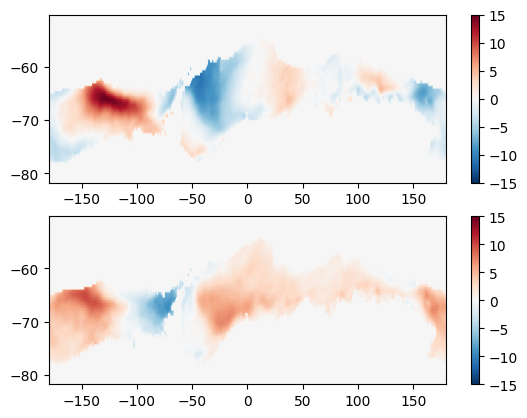

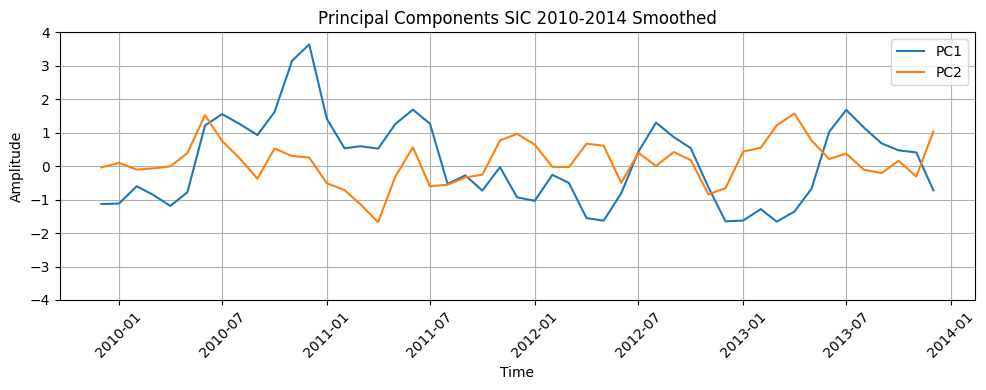

In [93]:
#EOF for 2010-2014


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_sic = SIC_eu_full_ds['seaice_xa_masked_final'].sel(
#     time=slice(timep1_sic_start.values, timep1_sic_end.values)
# ).rolling(time=4, center=True).mean()
smoothed_sic = SIC_eu_full_ds['seaice_xa_masked_final'].sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
).rolling(time=6, center=True).mean()
# Fill missing values (NaNs) with 0
smoothed_sic = smoothed_sic.ffill('time').bfill('time')

solver = Eof(sic, weights=weights_2d_masked)
eofvar_sic_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_sic_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_sic_sm_p1 = pcs[:, 0]
pc2_sic_sm_p1 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc1_sic_sm_p1.sel(time=slice(timep1_sic_start.values, timep1_sic_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc2_sic_sm_p1.sel(time=slice(timep1_sic_start.values, timep1_sic_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components SIC 2010-2014 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([9.26175943, 6.24177312])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


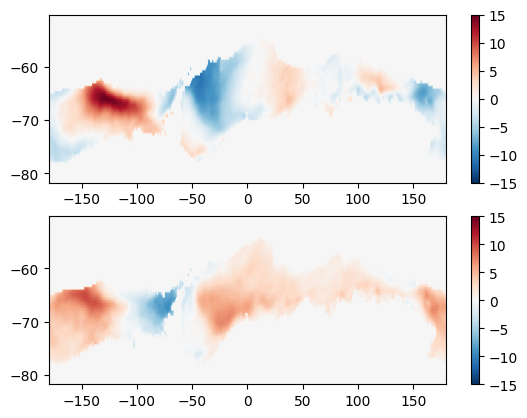

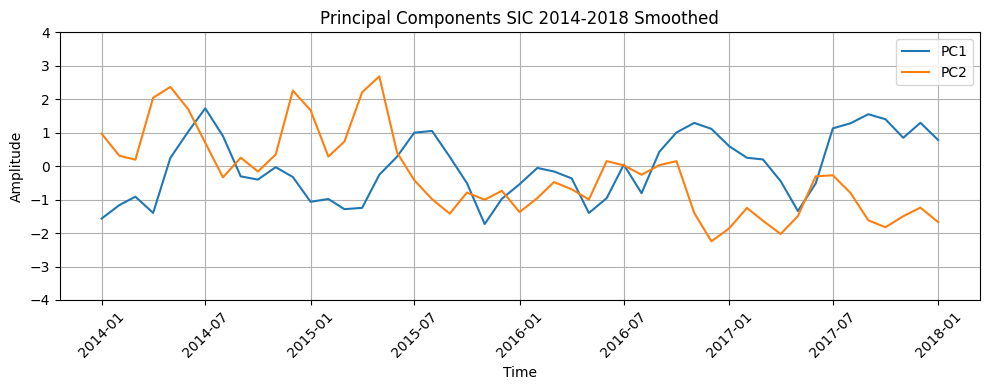

In [94]:
#EOF for 2014-2018


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_sic = SIC_eu_full_ds['seaice_xa_masked_final'].sel(
#     time=slice(timep2_sic_start.values, timep2_sic_end.values)
# ).rolling(time=4, center=True).mean()

smoothed_sic = SIC_eu_full_ds['seaice_xa_masked_final'].sel(
    time=slice(timep2_sic_start.values, timep2_sic_end.values)
).rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_sic = smoothed_sic.ffill('time').bfill('time')

solver = Eof(sic, weights=weights_2d_masked)
eofvar_sic_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_sic_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-15, 15)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_sic_sm_p2 = pcs[:, 0]
pc2_sic_sm_p2 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep2_sic_start.values, timep2_sic_end.values)
), pc1_sic_sm_p2.sel(time=slice(timep2_sic_start.values, timep2_sic_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep2_sic_start.values, timep2_sic_end.values)
), pc2_sic_sm_p2.sel(time=slice(timep2_sic_start.values, timep2_sic_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components SIC 2014-2018 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([28.33309804, 15.77000636])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


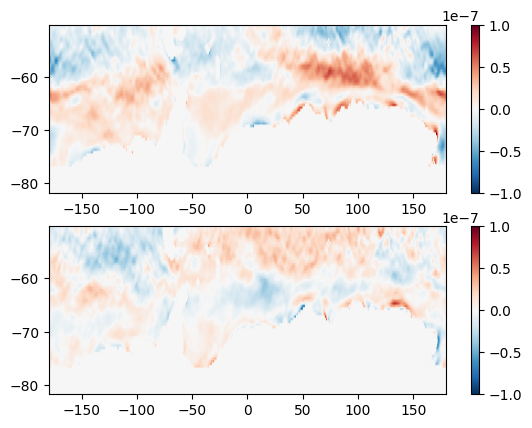

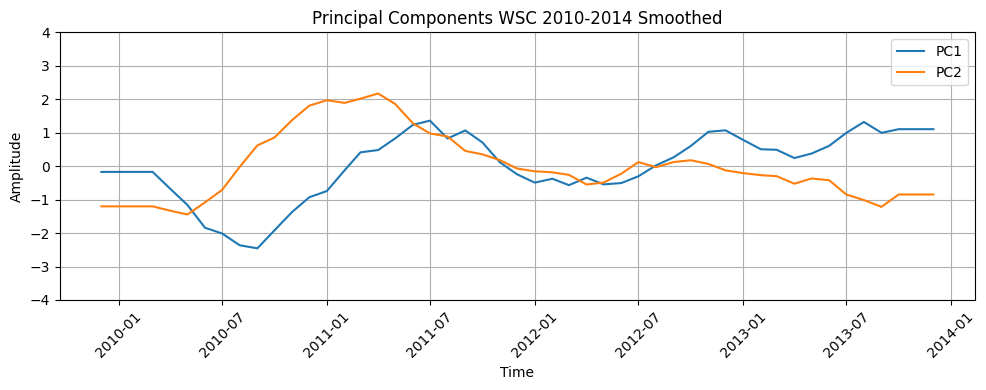

In [95]:
#EOF for 2010-2014


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_wsc = WSC_eumetsat_ds['WSC'].sel(
#     time=slice(timep1_start.values, timep1_end.values)
# ).rolling(time=4, center=True).mean()

smoothed_wsc = WSC_eumetsat_ds['WSC'].sel(
    time=slice(timep1_start.values, timep1_end.values)
).rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_wsc = smoothed_wsc.ffill('time').bfill('time')

solver = Eof(smoothed_wsc, weights=weights_2d_masked)
eofvar_wsc_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_wsc_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_wsc_sm_p1 = pcs[:, 0]
pc2_wsc_sm_p1 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc1_wsc_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc2_wsc_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components WSC 2010-2014 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([23.26843222, 16.76477453])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


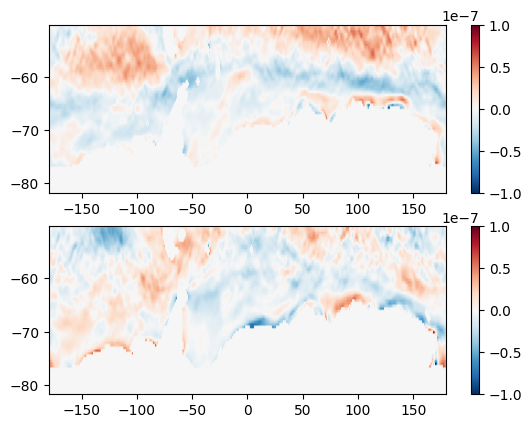

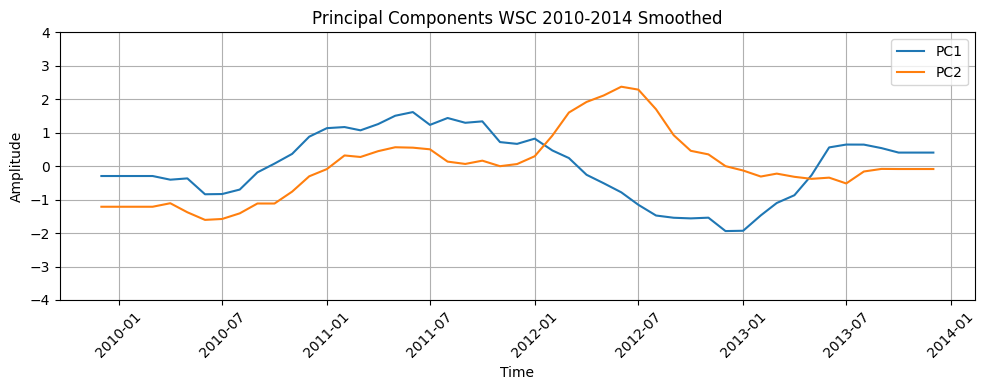

In [96]:
#EOF for 2014-2018


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_wsc_sm = WSC_eumetsat_ds['WSC'].sel(
#     time=slice(timep2_start.values, timep2_end.values)
# ).rolling(time=4, center=True).mean()

smoothed_wsc_sm = WSC_eumetsat_ds['WSC'].sel(
    time=slice(timep2_start.values, timep2_end.values)
).rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_wsc_sm = smoothed_wsc_sm.ffill('time').bfill('time')

solver = Eof(smoothed_wsc_sm, weights=weights_2d_masked)
eofvar_wsc_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_wsc_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-1e-7, 1e-7)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_wsc_sm_p2 = pcs[:, 0]
pc2_wsc_sm_p2 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc1_wsc_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc2_wsc_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components WSC 2010-2014 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([36.56495772, 10.22426205])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


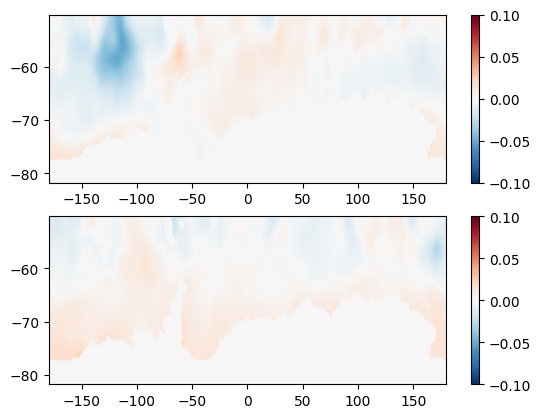

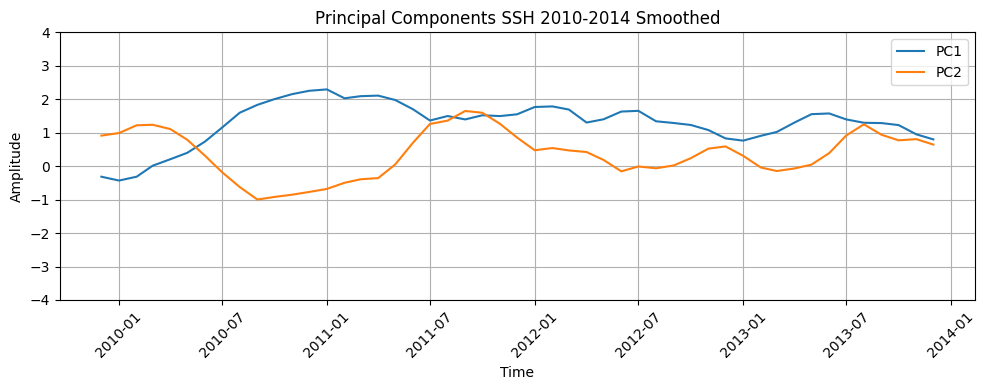

In [97]:
#EOF for 2010-2014


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_ssh_sm = dot_masked_ds['SSH'].sel(
#     time=slice(timep1_start.values, timep1_end.values)
# ).rolling(time=4, center=True).mean()

smoothed_ssh_sm = dot_masked_ds['SSH'].sel(
    time=slice(timep1_start.values, timep1_end.values)
).rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_ssh = smoothed_ssh.ffill('time').bfill('time')

solver = Eof(smoothed_ssh, weights=weights_2d_masked)
eofvar_ssh_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_ssh_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_ssh_sm_p1 = pcs[:, 0]
pc2_ssh_sm_p1 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc1_ssh_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc2_ssh_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components SSH 2010-2014 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



<xarray.DataArray 'variance_fractions' (mode: 2)> Size: 16B
array([36.56495772, 10.22426205])
Coordinates:
  * mode     (mode) int64 16B 0 1
Attributes:
    long_name:  variance_fractions
<class 'xarray.core.dataarray.DataArray'>


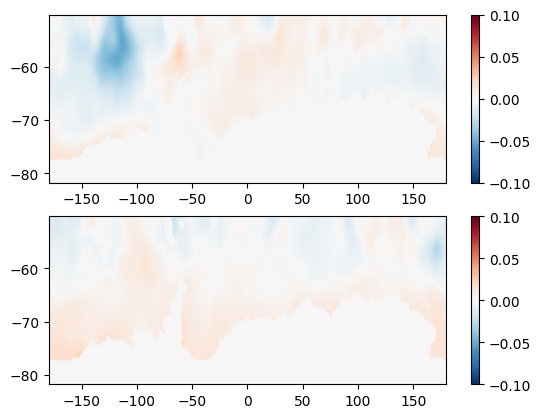

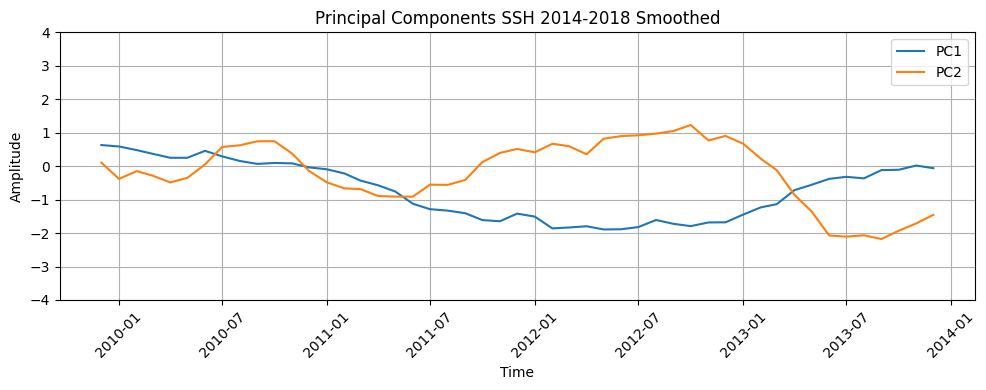

In [98]:
#EOF for 2010-2014


#smoothed_wsc = WSC_eumetsat_ds['WSC'].rolling(time=4, center=True).mean()
# Fill missing values (NaNs) with 0
#smoothed_wsc = smoothed_wsc.fillna(0)

# # Drop all time steps where data is fully NaN
# smoothed_wsc = smoothed_wsc.dropna(dim='time', how='all')

import eofs
from eofs.xarray import Eof

# smoothed_sic = SIC_eu_2015_xa['seaice_xa_masked'].rolling(time=4, center=True).mean()
# smoothed_ssh_sm = dot_masked_ds['SSH'].sel(
#     time=slice(timep2_start.values, timep2_end.values)
# ).rolling(time=4, center=True).mean()

smoothed_ssh_sm = dot_masked_ds['SSH'].sel(
    time=slice(timep2_start.values, timep2_end.values)
).rolling(time=6, center=True).mean()

# Fill missing values (NaNs) with 0
smoothed_ssh = smoothed_ssh.ffill('time').bfill('time')

solver = Eof(smoothed_ssh, weights=weights_2d_masked)
eofvar_ssh_sm = solver.varianceFraction(neigs=neofs) * 100
print(eofvar_ssh_sm)
neofs = 2
import eofs
from eofs.xarray import Eof

nlat, nlon = SIC_eu_2015_xa['lat'], SIC_eu_2015_xa['lon']
covmaps = solver.eofsAsCovariance(neofs=neofs)
print(type(covmaps))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

plt.close('all')
plt.figure()
plt.subplot(211)
cs = plt.imshow(covmaps[0][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)
plt.subplot(212)
cs = plt.imshow(covmaps[1][:: -1, :], cmap=plt.cm.RdBu_r, extent=extent, aspect='auto')
cs.set_clim(-0.1, 0.1)
cb = plt.colorbar(cs)

plt.show()

pcs = solver.pcs(pcscaling=1, npcs=neofs)

pc1_ssh_sm_p2 = pcs[:, 0]
pc2_ssh_sm_p2 = pcs[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc1_ssh_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)), label='PC1')
plt.plot(SIC_eu_full_ds.time.sel(
    time=slice(timep1_sic_start.values, timep1_sic_end.values)
), pc2_ssh_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)), label='PC2')
plt.legend()
plt.title("Principal Components SSH 2014-2018 Smoothed")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-4, 4)
plt.grid(True)

# Optional: rotate x labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [99]:
# ==== Extract Values by Period ====
# SOI and ZW3
soi_vals_p1 = smoothed_soi.sel(time=slice(timep1_start.values, timep1_end.values)).values
soi_vals_p2 = smoothed_soi.sel(time=slice(timep2_start.values, timep2_end.values)).values
zw3_vals_p1 = smoothed_zw3.sel(valid_time=slice(timep1_start.values, timep1_end.values)).values
zw3_vals_p2 = smoothed_zw3.sel(valid_time=slice(timep2_start.values, timep2_end.values)).values

# SIC
pc1_sic_p1 = pc1_sic_sm_p1.sel(time=slice(timep1_sic_start.values, timep1_sic_end.values)).values
pc2_sic_p1 = pc2_sic_sm_p1.sel(time=slice(timep1_sic_start.values, timep1_sic_end.values)).values
pc1_sic_p2 = pc1_sic_sm_p2.sel(time=slice(timep2_sic_start.values, timep2_sic_end.values)).values
pc2_sic_p2 = pc2_sic_sm_p2.sel(time=slice(timep2_sic_start.values, timep2_sic_end.values)).values

# WSC
pc1_wsc_p1 = pc1_wsc_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)).values
pc2_wsc_p1 = pc2_wsc_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)).values
pc1_wsc_p2 = pc1_wsc_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)).values
pc2_wsc_p2 = pc2_wsc_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)).values

# SSH
pc1_ssh_p1 = pc1_ssh_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)).values
pc2_ssh_p1 = pc2_ssh_sm_p1.sel(time=slice(timep1_start.values, timep1_end.values)).values
pc1_ssh_p2 = pc1_ssh_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)).values
pc2_ssh_p2 = pc2_ssh_sm_p2.sel(time=slice(timep2_start.values, timep2_end.values)).values

# ==== Create Data Matrices ====
# Period 1
data_matrix_p1 = np.vstack([
    soi_vals_p1, zw3_vals_p1,
    pc1_sic_p1, pc2_sic_p1,
    pc1_wsc_p1, pc2_wsc_p1,
    pc1_ssh_p1, pc2_ssh_p1
])

labels_p1 = [
    'SOI_P1', 'ZW3_P1',
    'PC1_SIC_P1', 'PC2_SIC_P1',
    'PC1_WSC_P1', 'PC2_WSC_P1',
    'PC1_SSH_P1', 'PC2_SSH_P1'
]

# Period 2
data_matrix_p2 = np.vstack([
    soi_vals_p2, zw3_vals_p2,
    pc1_sic_p2, pc2_sic_p2,
    pc1_wsc_p2, pc2_wsc_p2,
    pc1_ssh_p2, pc2_ssh_p2
])

labels_p2 = [
    'SOI_P2', 'ZW3_P2',
    'PC1_SIC_P2', 'PC2_SIC_P2',
    'PC1_WSC_P2', 'PC2_WSC_P2',
    'PC1_SSH_P2', 'PC2_SSH_P2'
]

# ==== Compute Correlation Matrices ====
# Period 1
corr_spear_p1, _ = spearmanr(data_matrix_p1, axis=1)
corr_spear_p1 = np.round(corr_spear_p1, 3)
corr_pearson_p1 = np.round(np.corrcoef(data_matrix_p1), 3)

# Period 2
corr_spear_p2, _ = spearmanr(data_matrix_p2, axis=1)
corr_spear_p2 = np.round(corr_spear_p2, 3)
corr_pearson_p2 = np.round(np.corrcoef(data_matrix_p2), 3)

# ==== Display Results ====
print('\n=== Pearson Correlation Matrix (P1) ===')
print(pd.DataFrame(corr_pearson_p1, index=labels_p1, columns=labels_p1))

print('\n=== Spearman Correlation Matrix (P1) ===')
print(pd.DataFrame(corr_spear_p1, index=labels_p1, columns=labels_p1))

print('\n=== Pearson Correlation Matrix (P2) ===')
print(pd.DataFrame(corr_pearson_p2, index=labels_p2, columns=labels_p2))

print('\n=== Spearman Correlation Matrix (P2) ===')
print(pd.DataFrame(corr_spear_p2, index=labels_p2, columns=labels_p2))



=== Pearson Correlation Matrix (P1) ===
            SOI_P1  ZW3_P1  PC1_SIC_P1  PC2_SIC_P1  PC1_WSC_P1  PC2_WSC_P1  \
SOI_P1       1.000  -0.201       0.474      -0.036      -0.332       0.474   
ZW3_P1      -0.201   1.000       0.007      -0.079      -0.081       0.225   
PC1_SIC_P1   0.474   0.007       1.000      -0.122      -0.226       0.483   
PC2_SIC_P1  -0.036  -0.079      -0.122       1.000      -0.240      -0.449   
PC1_WSC_P1  -0.332  -0.081      -0.226      -0.240       1.000      -0.000   
PC2_WSC_P1   0.474   0.225       0.483      -0.449      -0.000       1.000   
PC1_SSH_P1   0.630  -0.013       0.528      -0.179      -0.095       0.769   
PC2_SSH_P1  -0.582  -0.042      -0.412      -0.029       0.557      -0.504   

            PC1_SSH_P1  PC2_SSH_P1  
SOI_P1           0.630      -0.582  
ZW3_P1          -0.013      -0.042  
PC1_SIC_P1       0.528      -0.412  
PC2_SIC_P1      -0.179      -0.029  
PC1_WSC_P1      -0.095       0.557  
PC2_WSC_P1       0.769      -0.504

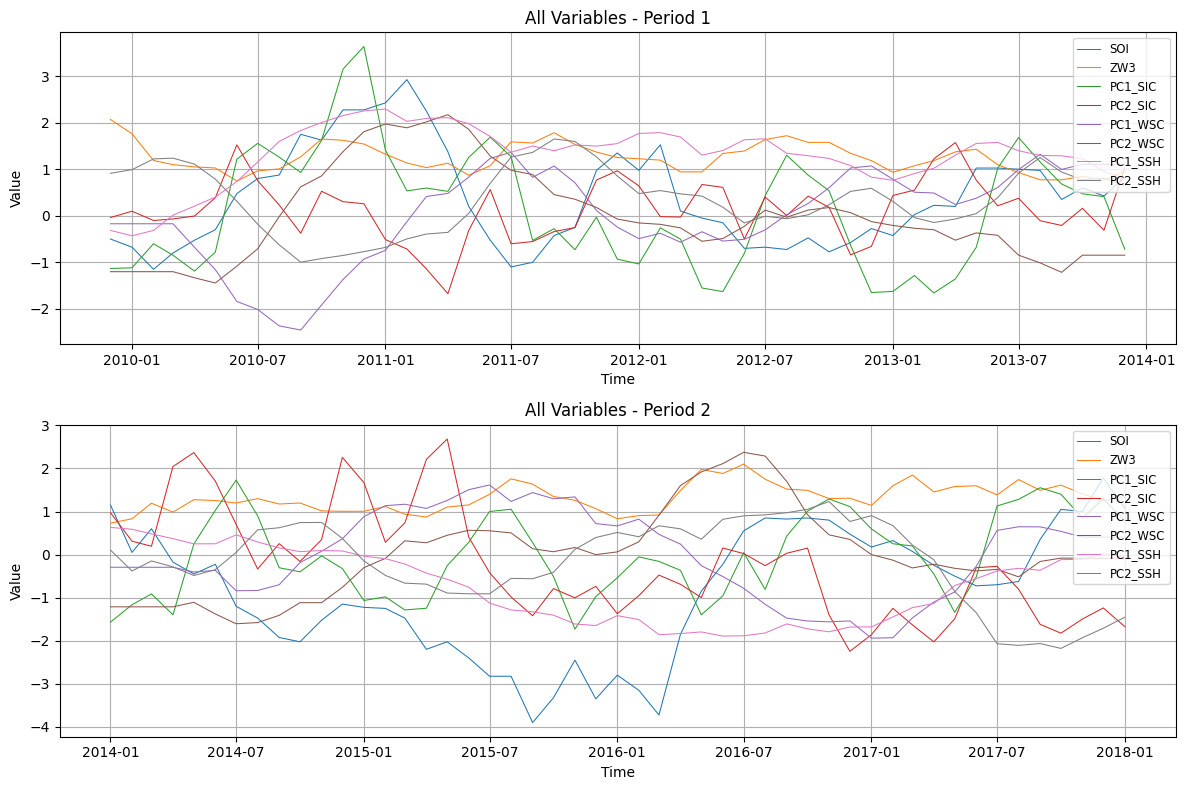

In [119]:
# Time arrays
time_p1 = smoothed_soi.sel(time=slice(timep1_start.values, timep1_end.values)).time.values
time_p2 = smoothed_soi.sel(time=slice(timep2_start.values, timep2_end.values)).time.values


import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,1, figsize=(12, 8))
# P1 Plot
axs[0].set_title('All Variables - Period 1')
axs[0].plot(time_p1, soi_vals_p1, label='SOI', lw = 0.75)
axs[0].plot(time_p1, zw3_vals_p1, label='ZW3', lw = 0.75)
axs[0].plot(time_p1, pc1_sic_p1, label='PC1_SIC', lw = 0.75)
axs[0].plot(time_p1, pc2_sic_p1, label='PC2_SIC', lw = 0.75)
axs[0].plot(time_p1, pc1_wsc_p1, label='PC1_WSC', lw = 0.75)
axs[0].plot(time_p1, pc2_wsc_p1, label='PC2_WSC', lw = 0.75)
axs[0].plot(time_p1, pc1_ssh_p1, label='PC1_SSH', lw = 0.75)
axs[0].plot(time_p1, pc2_ssh_p1, label='PC2_SSH', lw = 0.75)
axs[0].legend(loc='upper right', fontsize='small')
axs[0].grid(True)
axs[0].set_ylabel('Value')
axs[0].set_xlabel('Time')


# P2 Plot
axs[1].set_title('All Variables - Period 2')
axs[1].plot(time_p2, soi_vals_p2, label='SOI', lw = 0.75)
axs[1].plot(time_p2, zw3_vals_p2, label='ZW3', lw = 0.75)
axs[1].plot(time_p2, pc1_sic_p2, label='PC1_SIC', lw = 0.75)
axs[1].plot(time_p2, pc2_sic_p2, label='PC2_SIC', lw = 0.75)
axs[1].plot(time_p2, pc1_wsc_p2, label='PC1_WSC', lw = 0.75)
axs[1].plot(time_p2, pc2_wsc_p2, label='PC2_WSC', lw = 0.75)
axs[1].plot(time_p2, pc1_ssh_p2, label='PC1_SSH', lw = 0.75)
axs[1].plot(time_p2, pc2_ssh_p2, label='PC2_SSH', lw = 0.75)
axs[1].legend(loc='upper right', fontsize='small')
axs[1].grid(True)
axs[1].set_ylabel('Value')
axs[1].set_xlabel('Time')
plt.tight_layout()
plt.show()


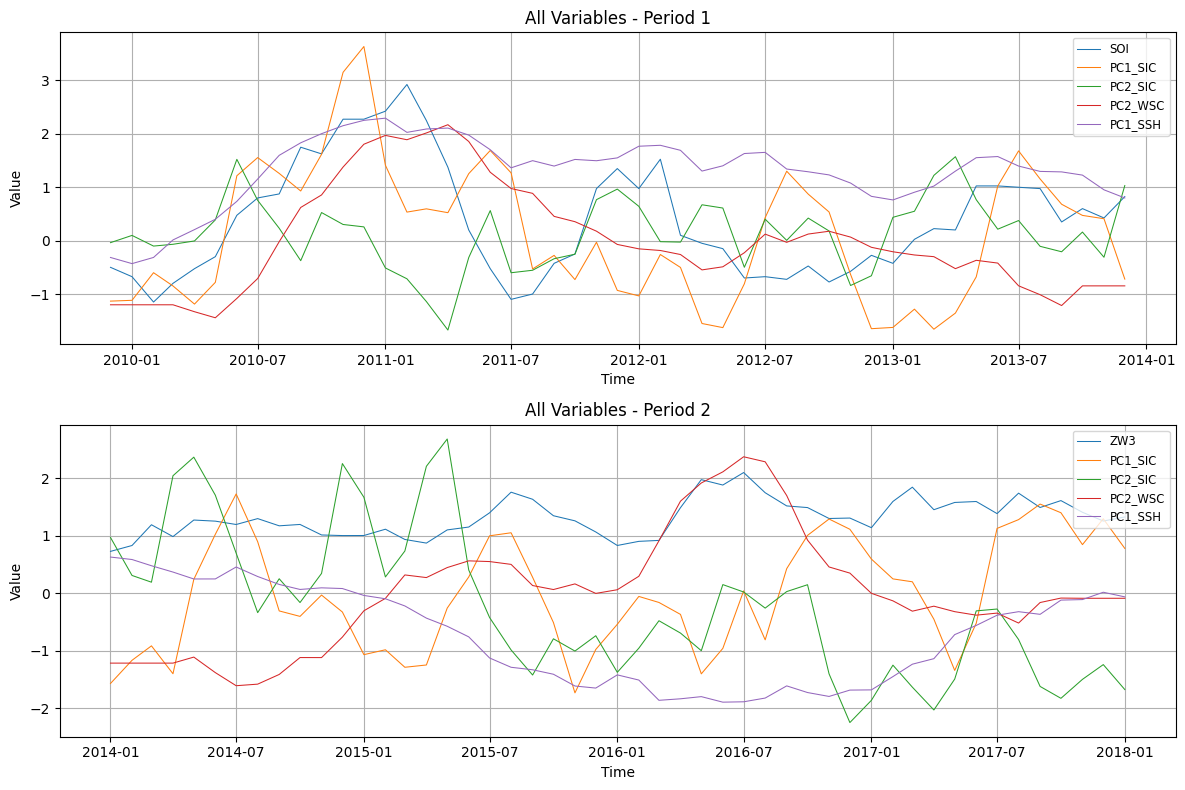

In [120]:
# Time arrays
time_p1 = smoothed_soi.sel(time=slice(timep1_start.values, timep1_end.values)).time.values
time_p2 = smoothed_soi.sel(time=slice(timep2_start.values, timep2_end.values)).time.values


import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,1, figsize=(12, 8))
# P1 Plot

axs[0].set_title('All Variables - Period 1')
axs[0].plot(time_p1, soi_vals_p1, label='SOI', lw = 0.75)

axs[0].plot(time_p1, pc1_sic_p1, label='PC1_SIC', lw = 0.75)
axs[0].plot(time_p1, pc2_sic_p1, label='PC2_SIC', lw = 0.75)

axs[0].plot(time_p1, pc2_wsc_p1, label='PC2_WSC', lw = 0.75)
axs[0].plot(time_p1, pc1_ssh_p1, label='PC1_SSH', lw = 0.75)

axs[0].legend(loc='upper right', fontsize='small')
axs[0].grid(True)
axs[0].set_ylabel('Value')
axs[0].set_xlabel('Time')


# P2 Plot

axs[1].set_title('All Variables - Period 2')

axs[1].plot(time_p2, zw3_vals_p2, label='ZW3', lw = 0.75)
axs[1].plot(time_p2, pc1_sic_p2, label='PC1_SIC', lw = 0.75)
axs[1].plot(time_p2, pc2_sic_p2, label='PC2_SIC', lw = 0.75)

axs[1].plot(time_p2, pc2_wsc_p2, label='PC2_WSC', lw = 0.75)
axs[1].plot(time_p2, pc1_ssh_p2, label='PC1_SSH', lw = 0.75)

axs[1].legend(loc='upper right', fontsize='small')
axs[1].grid(True)
axs[1].set_ylabel('Value')
axs[1].set_xlabel('Time')
plt.tight_layout()
plt.show()
